# Model Estimation & Selection

Simulated ARMA (true order known) for the information-criteria behaviour, and the bakery daily sales from [EDA.ipynb](EDA.ipynb) for residuals and forecast metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

bakery = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
y = (bakery[bakery["unique_id"] == "TRADITIONAL BAGUETTE"]
     .sort_values("ds").set_index("ds")["y"].asfreq("D"))
X = pd.DataFrame({"is_closed": (y == 0).astype(float)}, index=y.index)

H = 28
train, test = y[:-H], y[-H:]
x_tr, x_te = X[:-H], X[-H:]
print(f"train {len(train)}   test {len(test)}   zeros in test: {int((test == 0).sum())}")

train 609   test 28   zeros in test: 1


## 1. Information criteria

**The problem.** Log-likelihood never decreases when you add a parameter, so "maximise the likelihood" always picks the biggest model. An information criterion adds a penalty for complexity:

$$\text{AIC} = -2\log L + 2k \qquad\qquad \text{BIC} = -2\log L + k\log n$$

with $k$ = number of estimated parameters (including the variance) and $n$ = observations. **Lower is better** for both.

**AICc** — a small-sample correction, recommended whenever $n/k < 40$:

$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n-k-1}$$

**Where they come from, and why the penalties differ:**

| | AIC | BIC |
|---|---|---|
| Derived from | Kullback-Leibler divergence — expected out-of-sample fit | Bayesian posterior model probability |
| Asks | which model **predicts** best? | which model is **true**? |
| Penalty per parameter | 2 | $\log n$ |
| As $n \to \infty$ | **efficient**, but not consistent — keeps over-selecting | **consistent** — picks the true model with probability → 1 |
| Assumes true model is in the set | no | yes |

With $n = 609$ here, $\log n = 6.41$ — BIC charges more than **three times** AIC per parameter, so it always prefers models at least as small.

**How to read them.** The absolute value is meaningless (it depends on $n$ and scaling); only **differences between models on identical data** matter. A common rule of thumb for $\Delta$AIC: < 2 is indistinguishable, 4–7 is meaningfully worse, > 10 is decisive.

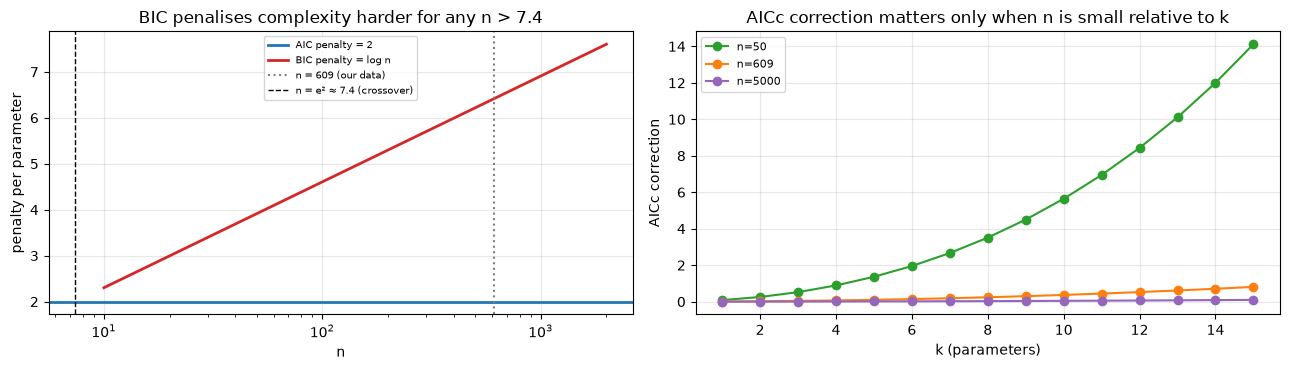

n = 609  ->  AIC penalty 2.00 per parameter, BIC penalty 6.41


In [2]:
n_grid = np.arange(10, 2001)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].axhline(2, color="tab:blue", lw=2, label="AIC penalty = 2")
axes[0].plot(n_grid, np.log(n_grid), color="tab:red", lw=2, label="BIC penalty = log n")
axes[0].axvline(609, color="grey", ls=":", label="n = 609 (our data)")
axes[0].axvline(np.exp(2), color="black", ls="--", lw=1, label="n = e² ≈ 7.4 (crossover)")
axes[0].set_xscale("log"); axes[0].set_xlabel("n"); axes[0].set_ylabel("penalty per parameter")
axes[0].set_title("BIC penalises complexity harder for any n > 7.4")
axes[0].legend(fontsize=7)

k_grid = np.arange(1, 16)
for n_, c in [(50, "tab:green"), (609, "tab:orange"), (5000, "tab:purple")]:
    axes[1].plot(k_grid, 2 * k_grid * (k_grid + 1) / (n_ - k_grid - 1), marker="o", color=c, label=f"n={n_}")
axes[1].set_xlabel("k (parameters)"); axes[1].set_ylabel("AICc correction")
axes[1].set_title("AICc correction matters only when n is small relative to k")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"n = 609  ->  AIC penalty 2.00 per parameter, BIC penalty {np.log(609):.2f}")

### Consistency vs efficiency, measured

Simulate from a known AR(2), fit AR(1)…AR(6), and record which order each criterion picks. Repeat 200 times at two sample sizes.

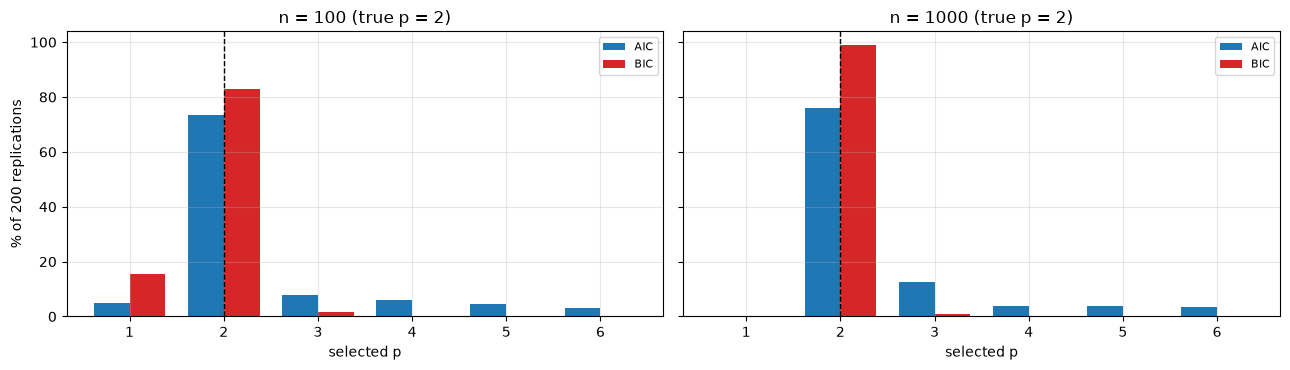

n=  100  AIC: 74% correct  BIC: 83% correct
n= 1000  AIC: 76% correct  BIC: 99% correct


In [3]:
TRUE_P = 2
proc = ArmaProcess(np.r_[1, -np.array([0.6, -0.3])], [1])

def order_recovery(n, reps=200, pmax=6):
    picks = {"AIC": [], "BIC": []}
    for s in range(reps):
        x = proc.generate_sample(n, distrvs=np.random.default_rng(s).standard_normal)
        aics, bics = [], []
        for p in range(1, pmax + 1):
            try:
                f = ARIMA(x, order=(p, 0, 0)).fit()
                aics.append(f.aic); bics.append(f.bic)
            except Exception:
                aics.append(np.inf); bics.append(np.inf)
        picks["AIC"].append(int(np.argmin(aics)) + 1)
        picks["BIC"].append(int(np.argmin(bics)) + 1)
    return picks

results = {n: order_recovery(n) for n in (100, 1000)}     # takes a few minutes

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, (n, picks) in zip(axes, results.items()):
    w = 0.38
    for off, (crit, col) in zip((-w/2, w/2), [("AIC", "tab:blue"), ("BIC", "tab:red")]):
        counts = pd.Series(picks[crit]).value_counts().reindex(range(1, 7), fill_value=0)
        ax.bar(counts.index + off, 100 * counts / len(picks[crit]), width=w, color=col, label=crit)
    ax.axvline(TRUE_P, color="black", ls="--", lw=1)
    ax.set_xlabel("selected p"); ax.set_title(f"n = {n} (true p = 2)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("% of 200 replications")
plt.tight_layout(); plt.show()

for n, picks in results.items():
    print(f"n={n:5d}  " + "  ".join(
        f"{c}: {100*np.mean(np.array(picks[c]) == TRUE_P):.0f}% correct" for c in ("AIC", "BIC")))

**AIC 74% → 76% correct as $n$ goes from 100 to 1000; BIC 83% → 99%.**

That is consistency versus efficiency in one picture. BIC converges on the true order, while AIC's error rate plateaus — its over-selection does not vanish with more data, because the penalty of 2 stays fixed while the likelihood gain from a spurious parameter does not shrink fast enough. At $n=100$ BIC errs the other way, **under**-selecting to AR(1) in a sizeable minority of runs (visible as the AR(1) bar in the left panel): a heavy penalty is costly when data is scarce.

→ BIC when you want the *right structure*; AIC when you want the *best forecasts*. And neither is a substitute for out-of-sample validation, as the next cell shows.

In [4]:
specs = [("ARIMA(1,1,1)",           (1, 1, 1), (0, 0, 0, 0), False),
         ("ARIMA(2,1,2)",           (2, 1, 2), (0, 0, 0, 0), False),
         ("SARIMA(1,1,1)(1,1,1)₇",  (1, 1, 1), (1, 1, 1, 7), False),
         ("SARIMA(2,1,2)(1,1,1)₇",  (2, 1, 2), (1, 1, 1, 7), False),
         ("SARIMAX +is_closed",     (1, 1, 1), (1, 1, 1, 7), True)]

rows, fitted = [], {}
for name, order, sorder, use_x in specs:
    kw = dict(order=order, seasonal_order=sorder,
              enforce_stationarity=False, enforce_invertibility=False)
    m = SARIMAX(train, exog=x_tr, **kw).fit(disp=False) if use_x else SARIMAX(train, **kw).fit(disp=False)
    f = (m.get_forecast(H, exog=x_te) if use_x else m.get_forecast(H)).predicted_mean.values
    k, n_ = len(m.params), m.nobs
    fitted[name] = m
    rows.append({"model": name, "k": k, "logLik": round(m.llf, 1),
                 "AIC": round(m.aic, 1), "AICc": round(m.aic + 2*k*(k+1)/(n_-k-1), 1),
                 "BIC": round(m.bic, 1),
                 "test MAE": round(np.abs(test.values - f).mean(), 2)})

ic = pd.DataFrame(rows)
ic["ΔAIC"] = (ic["AIC"] - ic["AIC"].min()).round(1)
ic

,model,k,logLik,AIC,AICc,BIC,test MAE,ΔAIC
0,"ARIMA(1,1,1)",3,-3611.7,7229.5,7229.5,7242.7,125.57,698.1
1,"ARIMA(2,1,2)",5,-3594.7,7199.3,7199.4,7221.3,116.84,667.9
2,"SARIMA(1,1,1)(1,1,1)₇",5,-3321.5,6653.0,6653.1,6674.9,80.54,121.6
3,"SARIMA(2,1,2)(1,1,1)₇",7,-3309.4,6632.8,6632.9,6663.4,135.34,101.4
4,SARIMAX +is_closed,6,-3259.7,6531.4,6531.6,6557.7,35.74,0.0


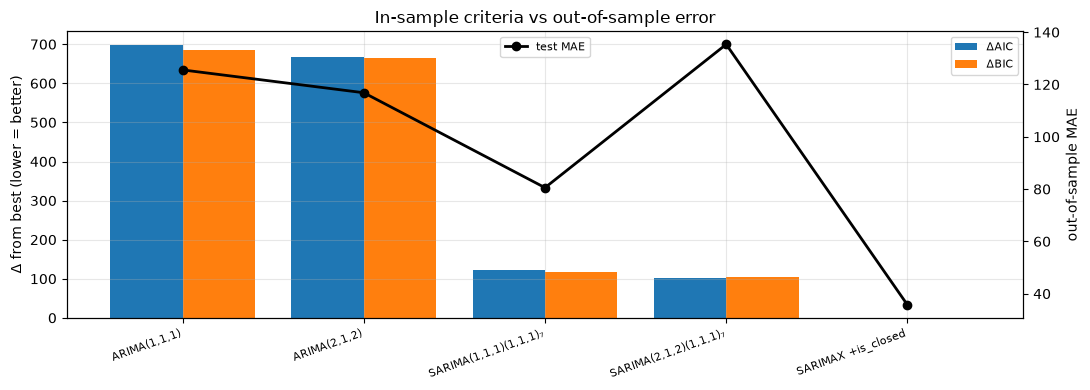

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
xs = np.arange(len(ic))
ax.bar(xs - 0.2, ic["AIC"] - ic["AIC"].min(), width=0.4, label="ΔAIC")
ax.bar(xs + 0.2, ic["BIC"] - ic["BIC"].min(), width=0.4, label="ΔBIC")
ax.set_xticks(xs, ic["model"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Δ from best (lower = better)")
ax2 = ax.twinx()
ax2.plot(xs, ic["test MAE"], color="black", marker="o", lw=2, label="test MAE")
ax2.set_ylabel("out-of-sample MAE"); ax2.grid(False)
ax.legend(loc="upper right", fontsize=8); ax2.legend(loc="upper center", fontsize=8)
ax.set_title("In-sample criteria vs out-of-sample error")
plt.tight_layout(); plt.show()

**The warning case is `SARIMA(2,1,2)(1,1,1)₇`.** Both criteria prefer it to the simpler `SARIMA(1,1,1)(1,1,1)₇` — AIC 6632.8 vs 6653.0, BIC 6663.4 vs 6674.9 — yet its out-of-sample MAE is **135.3 against 80.5**, nearly 70% worse. The extra AR and MA terms fit training noise.

Information criteria are **in-sample** estimates of out-of-sample fit, and that estimate can fail. Use them to shortlist, then confirm on held-out data.

Here the model that wins on every criterion *and* out-of-sample is `SARIMAX +is_closed` — because it adds real information (the closure calendar) rather than flexibility. AICc barely differs from AIC throughout, since $n/k \geq 87$ for every model.

## 2. Residual analysis

If the model captured everything predictable, the residuals $\hat\varepsilon_t = y_t - \hat{y}_t$ should be **white noise**. Four checks, in order of importance:

| # | Property | Test | Consequence if violated |
|---|---|---|---|
| 1 | zero mean | $\bar{\hat\varepsilon} \approx 0$ | forecasts biased — fixable by adding the mean back |
| 2 | no autocorrelation | Ljung-Box, residual ACF | **predictable structure left** — the serious one |
| 3 | constant variance | residuals vs time; Levene | intervals wrong width in places |
| 4 | normality | Jarque-Bera, Q-Q | point forecasts fine, **intervals unreliable** |

Only (1) and (2) affect the point forecast. (3) and (4) affect the *uncertainty*.

**Ljung-Box** tests the joint null that the first $h$ autocorrelations are all zero, so — like KPSS — **$p > 0.05$ is the good outcome**:

$$Q(h) = n(n+2)\sum_{k=1}^{h}\frac{\hat\rho_k^2}{n-k} \sim \chi^2_{h-m}$$

with $m$ the number of fitted ARMA parameters.

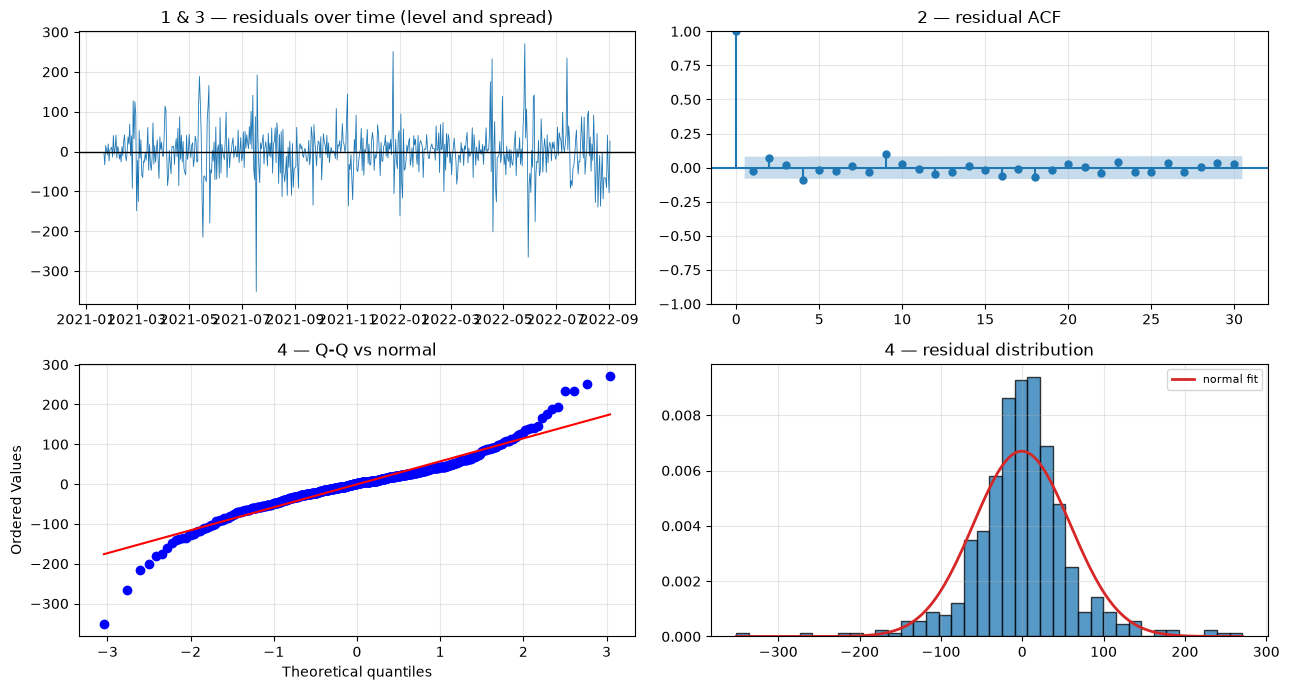

In [6]:
best = fitted["SARIMAX +is_closed"]
resid = best.resid[20:]                       # drop the state-space burn-in

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(resid.index, resid.values, lw=0.6)
axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].set_title("1 & 3 — residuals over time (level and spread)")

plot_acf(resid, lags=30, ax=axes[0, 1])
axes[0, 1].set_title("2 — residual ACF")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("4 — Q-Q vs normal")

axes[1, 1].hist(resid, bins=40, density=True, edgecolor="black", alpha=0.75)
xs = np.linspace(resid.min(), resid.max(), 200)
axes[1, 1].plot(xs, norm.pdf(xs, resid.mean(), resid.std()), lw=2, color="tab:red", label="normal fit")
axes[1, 1].legend(fontsize=8); axes[1, 1].set_title("4 — residual distribution")

plt.tight_layout(); plt.show()

In [7]:
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
half = len(resid) // 2
lev_p = stats.levene(resid[:half], resid[half:])[1]

print(f"1. mean          {resid.mean():8.3f}   (std {resid.std():.2f})")
print("2. Ljung-Box p  ", {L: round(acorr_ljungbox(resid, lags=[L], return_df=True)['lb_pvalue'].iloc[0], 4)
                           for L in (7, 14, 21)})
print(f"3. variance      {resid[:half].var():.0f} vs {resid[half:].var():.0f}   Levene p = {lev_p:.4f}")
print(f"4. Jarque-Bera p {jb_p:.3g}   skew {skew:+.2f}   kurtosis {kurt:.2f}")

1. mean            -0.595   (std 59.55)
2. Ljung-Box p   {7: np.float64(0.2085), 14: np.float64(0.1668), 21: np.float64(0.2604)}
3. variance      3452 vs 3652   Levene p = 0.9884
4. Jarque-Bera p 1.92e-126   skew -0.09   kurtosis 7.85


**Three of four pass.** The mean is ≈ 0, Ljung-Box gives p = 0.21 / 0.17 / 0.26 (no autocorrelation left), and the variance is stable across halves (Levene p = 0.99).

**Normality fails badly**: kurtosis **7.85** against 3 for a normal, Jarque-Bera p ≈ 1.9e-126. The Q-Q plot bends at both ends — occasional days far outside what a Gaussian allows.

→ The point forecasts are trustworthy; the **prediction intervals are not**. Fat tails mean a nominal 95% interval will be breached more often than 5% of the time. Use bootstrapped or empirical quantiles instead.

## 3. Forecast accuracy metrics

For actuals $y_t$ and forecasts $\hat{y}_t$ over $n$ points, $e_t = y_t - \hat{y}_t$.

**MAE** — average absolute error, in the units of the data:

$$\text{MAE} = \frac{1}{n}\sum |e_t|$$

Minimised by the **median** of the predictive distribution. Robust to outliers.

**RMSE** — square before averaging, so large errors dominate:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum e_t^2}$$

Minimised by the **mean**. Always ≥ MAE; the **ratio RMSE/MAE indicates how outlier-heavy the errors are** (1.0 = all errors equal).

**MAPE** — relative error, unit-free:

$$\text{MAPE} = \frac{100}{n}\sum \left|\frac{e_t}{y_t}\right|$$

Two serious defects: it is **undefined when $y_t = 0$** and explodes for small $y_t$; and it is **asymmetric**, penalising over-forecasts more than under-forecasts (an over-forecast can cost >100%, an under-forecast at most 100%), which biases models low.

**sMAPE** — the attempted fix:

$$\text{sMAPE} = \frac{100}{n}\sum \frac{|e_t|}{(|y_t| + |\hat{y}_t|)/2}$$

Bounded at 200% and defined unless both are zero — but **still asymmetric**, now in the opposite direction. (`utilsforecast` reports the 0–1 form, $|e_t|/(|y_t|+|\hat{y}_t|)$; multiply by 200 for the classic percentage.)

**CRPS** — the only one here that scores a **whole predictive distribution** rather than a point:

$$\text{CRPS}(F, y) = \int_{-\infty}^{\infty}\big(F(x) - \mathbb{1}\{x \ge y\}\big)^2\,dx$$

It compares the forecast CDF $F$ against the step function at the observed $y$. It is a **proper** scoring rule — minimised only by the true distribution, so it rewards being both accurate *and* honestly calibrated. It reduces to MAE when the forecast is a point mass, which makes the two directly comparable in the same units. For a Gaussian forecast there is a closed form, with $z = (y-\mu)/\sigma$:

$$\text{CRPS}\big(\mathcal{N}(\mu,\sigma^2), y\big) = \sigma\left[z\big(2\Phi(z)-1\big) + 2\phi(z) - \tfrac{1}{\sqrt{\pi}}\right]$$

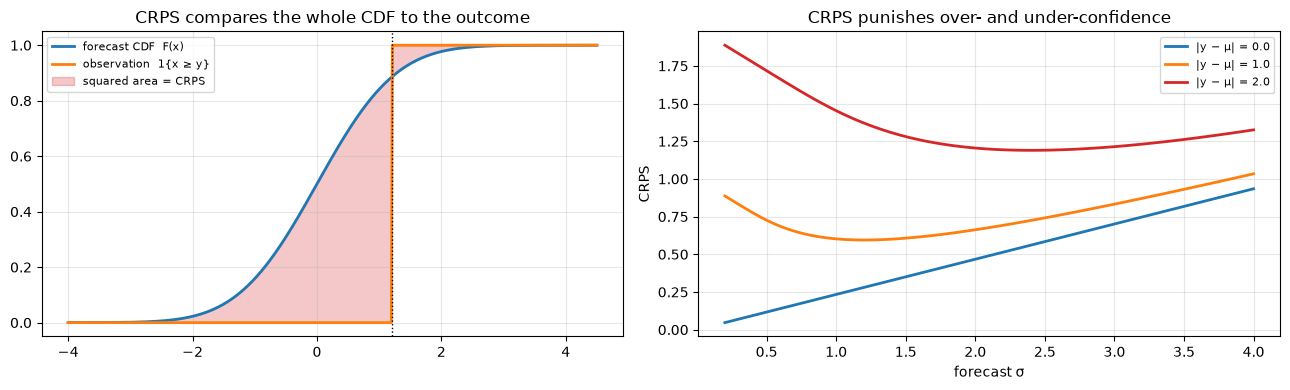

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mu_, sd_, obs = 0.0, 1.0, 1.2
grid = np.linspace(-4, 4.5, 500)
axes[0].plot(grid, norm.cdf(grid, mu_, sd_), lw=2, label="forecast CDF  F(x)")
axes[0].plot(grid, (grid >= obs).astype(float), lw=2, label="observation  1{x ≥ y}")
axes[0].fill_between(grid, norm.cdf(grid, mu_, sd_), (grid >= obs).astype(float),
                     alpha=0.25, color="tab:red", label="squared area = CRPS")
axes[0].axvline(obs, color="black", ls=":", lw=1)
axes[0].set_title("CRPS compares the whole CDF to the outcome")
axes[0].legend(fontsize=8)

def crps_norm(y_, mu_, sd_):
    z = (y_ - mu_) / sd_
    return sd_ * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

sds = np.linspace(0.2, 4, 100)
for err, c in [(0.0, "tab:blue"), (1.0, "tab:orange"), (2.0, "tab:red")]:
    axes[1].plot(sds, crps_norm(err, 0.0, sds), color=c, lw=2, label=f"|y − μ| = {err}")
axes[1].set_xlabel("forecast σ"); axes[1].set_ylabel("CRPS")
axes[1].set_title("CRPS punishes over- and under-confidence")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The right panel is why CRPS is worth the extra work: for a perfect point forecast (blue) CRPS is minimised by $\sigma \to 0$, but when the forecast is off (red) an over-confident small $\sigma$ is punished hard. A point metric cannot see that trade-off at all.

### Where MAE, RMSE and MAPE break

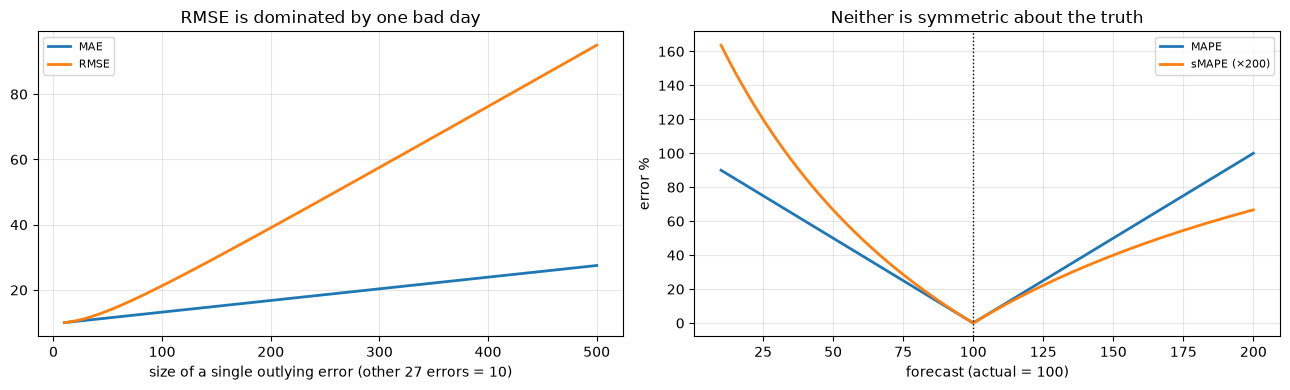

one error of   10:  MAE  10.00   RMSE  10.00   ratio 1.00
one error of   50:  MAE  11.43   RMSE  13.63   ratio 1.19
one error of  100:  MAE  13.21   RMSE  21.30   ratio 1.61
one error of  500:  MAE  27.50   RMSE  95.00   ratio 3.45

actual = 100, symmetric miss of 50 in each direction
  forecast  50:  MAPE 50%   sMAPE 66.7%
  forecast 150:  MAPE 50%   sMAPE 40.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# outlier sensitivity
mags = np.linspace(10, 500, 100)
mae_v = [np.abs(np.r_[np.repeat(10.0, 27), m]).mean() for m in mags]
rmse_v = [np.sqrt((np.r_[np.repeat(10.0, 27), m] ** 2).mean()) for m in mags]
axes[0].plot(mags, mae_v, lw=2, label="MAE")
axes[0].plot(mags, rmse_v, lw=2, label="RMSE")
axes[0].set_xlabel("size of a single outlying error (other 27 errors = 10)")
axes[0].set_title("RMSE is dominated by one bad day")
axes[0].legend(fontsize=8)

# asymmetry of MAPE and sMAPE
fcst = np.linspace(10, 200, 200)
actual = 100.0
axes[1].plot(fcst, 100 * np.abs(actual - fcst) / actual, lw=2, label="MAPE")
axes[1].plot(fcst, 200 * np.abs(actual - fcst) / (actual + fcst), lw=2, label="sMAPE (×200)")
axes[1].axvline(actual, color="black", ls=":", lw=1)
axes[1].set_xlabel("forecast (actual = 100)"); axes[1].set_ylabel("error %")
axes[1].set_title("Neither is symmetric about the truth")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for e_ in (10, 50, 100, 500):
    err = np.r_[np.repeat(10.0, 27), e_]
    print(f"one error of {e_:4d}:  MAE {np.abs(err).mean():6.2f}   "
          f"RMSE {np.sqrt((err**2).mean()):6.2f}   ratio {np.sqrt((err**2).mean())/np.abs(err).mean():.2f}")

print("\nactual = 100, symmetric miss of 50 in each direction")
for f_ in (50, 150):
    print(f"  forecast {f_:3d}:  MAPE {100*abs(100-f_)/100:.0f}%   "
          f"sMAPE {200*abs(100-f_)/(100+f_):.1f}%")

**RMSE/MAE rises from 1.00 to 3.45** as one error grows from 10 to 500 — that ratio is a free diagnostic for whether a few days dominate your error.

**Both percentage metrics are asymmetric.** Missing by 50 in either direction gives MAPE = 50% both ways only because the denominator is fixed — but the *shape* of the curve is not symmetric, and sMAPE explicitly scores the under-forecast (66.7%) worse than the over-forecast (40.0%). Optimising either one nudges the model in a direction that has nothing to do with the cost of the errors.

### Applied to the bakery forecast

MAE                        35.742
RMSE                       45.790
MAPE (%)                      inf
MAPE excl. zeros (%)       18.512
sMAPE (%)                  27.758
CRPS                       38.011

RMSE/MAE ratio 1.28
zeros in the test window: 1  ->  MAPE is inf


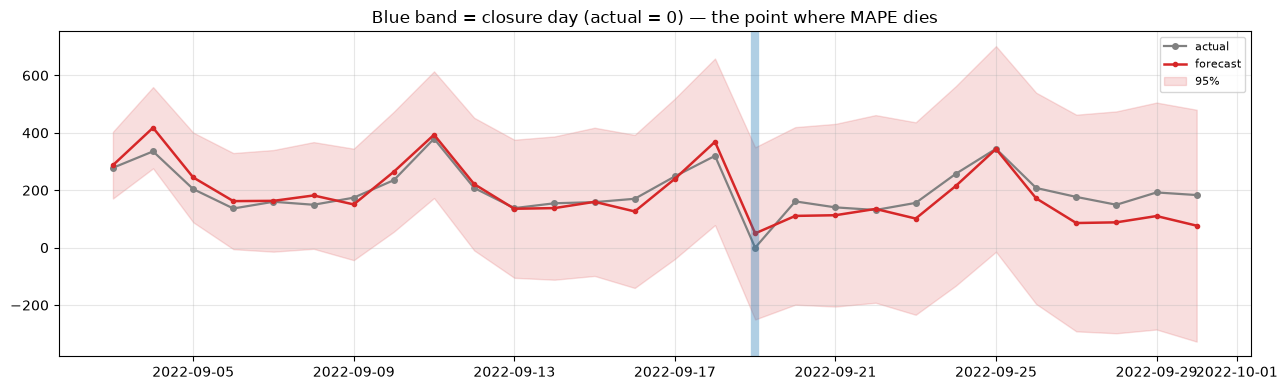

In [10]:
res = best.get_forecast(H, exog=x_te)
mu, sd = res.predicted_mean.values, res.se_mean.values
a = test.values
e = a - mu

with np.errstate(divide="ignore", invalid="ignore"):
    mape_terms = np.abs(e / a)

nz = a != 0
scores = {
    "MAE":                np.abs(e).mean(),
    "RMSE":               np.sqrt((e ** 2).mean()),
    "MAPE (%)":           100 * mape_terms.mean(),
    "MAPE excl. zeros (%)": 100 * np.abs(e[nz] / a[nz]).mean(),
    "sMAPE (%)":          200 * (np.abs(e) / (np.abs(a) + np.abs(mu))).mean(),
    "CRPS":               crps_norm(a, mu, sd).mean(),
}
for k, v in scores.items():
    print(f"{k:22s} {v:10.3f}")

print(f"\nRMSE/MAE ratio {scores['RMSE']/scores['MAE']:.2f}")
print(f"zeros in the test window: {int((a == 0).sum())}  ->  MAPE is {mape_terms.max()}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, a, lw=1.6, color="grey", marker="o", ms=4, label="actual")
ax.plot(test.index, mu, lw=1.8, color="tab:red", marker="o", ms=3, label="forecast")
ax.fill_between(test.index, mu - 1.96 * sd, mu + 1.96 * sd, alpha=0.15, color="tab:red", label="95%")
for d_ in test.index[a == 0]:
    ax.axvline(d_, color="tab:blue", alpha=0.35, lw=6)
ax.set_title("Blue band = closure day (actual = 0) — the point where MAPE dies")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**MAPE is `inf`.** The test window contains one closure day with $y_t = 0$, and division by zero ends the calculation. Dropping that day gives 18.5%, but silently deleting the observations a metric cannot handle is exactly how a metric misleads you — the closure days are real, and a metric that cannot score them is the wrong metric for this series.

The rest: MAE 35.74, RMSE 45.79 (ratio 1.28, so errors are moderately outlier-driven), sMAPE 27.8%, and **CRPS 38.01**. CRPS sits slightly above MAE — as expected, since it charges for the width of the predictive distribution as well as the location of its centre, and section 2 showed those intervals are built on fat-tailed residuals.

**Choosing:** MAE for a cost linear in error; RMSE when large misses hurt disproportionately; neither MAPE nor sMAPE on a series that can hit zero; CRPS whenever the forecast is a distribution and you care whether the uncertainty is honest.